In [443]:
import pandas as pd 
import numpy as np 

In [444]:
df=pd.read_csv('D:\projects\project1\datasets\logistic_regression_data_2features.csv')
df['feature0']=np.full((len(df),),1)

In [445]:
df.head()

,feature1,feature2,target,feature0
0,-4.774390,-1.128783,1,1
1,-3.135826,-0.535217,1,1
2,4.465239,-2.012233,0,1
3,-4.281804,-0.878251,1,1
4,3.407545,-2.664642,0,1


In [446]:
df.describe()

,feature1,feature2,target,feature0
count,100.000000,100.000000,100.000000,100.0
mean,0.140595,-2.635432,0.510000,1.0
std,3.863555,0.974850,0.502418,0.0
min,-5.077115,-5.029281,0.000000,1.0
25%,-3.712167,-3.384717,0.000000,1.0
50%,0.182935,-2.657511,1.000000,1.0
75%,3.827366,-2.012399,1.000000,1.0
max,6.205070,-0.535217,1.000000,1.0


In [447]:
df.shape

(100, 4)

In [448]:
x=df.drop(columns=['target'],inplace=False).to_numpy()
y=df['target'].to_numpy()


In [449]:
class sigmoid:
    def __init__(self,lr=0.01,epoch=100):
        self.lr=lr
        self.epoch=epoch
        self.weight=None
    def fit(self,x,y):
        x=np.asarray(x)
        y=np.asarray(y)
        b=np.random.randint(0,len(x),self.epoch)
        self.weight=np.full((len(x[0]),),0.5)
        for i in b:
            self.weight=self.weight-self.lr*(self.sig(x[i])-y[i])*x[i]
        return self.weight
    def sig(self,x):
        a=x@self.weight
        b=1/(1+np.exp(-a))
        return b
    def predict(self,x):
        weight=self.weight
        x=np.asarray(x)
        z=x@weight
        return (z>0).astype(int)

class split:
    def __init__(self,test_size=0.2):
        self.test_size=test_size
        
    def train_test_split(self,x,y):
        x=np.asarray(x)
        y=np.asarray(y)
        d=int((1-self.test_size)*len(x))
        a=np.random.choice(range(0,len(x)),size=d,replace=False)
        X_train=[]
        X_test=[]
        Y_train=[]
        Y_test=[]
        b=[]
        for i in a:
            X_train.append(x[i])
            Y_train.append(y[i])
        for j in range(0,len(x)):
            if j not in a:
                b.append(j)
        for k in b:
            X_test.append(x[k])
            Y_test.append(y[k])
        return np.array(X_train),np.array(X_test),np.array(Y_train),np.array(Y_test)
    ## we can use this one too as this whole train_test_split is complicated 
    #a=np.random.choice(range(0,len(x)),size=d,replace=false)
    #b=np.array([i for i in range len(x) if i not in set(a)])
    #x_train=x[a]
    #y_train=y[a]
    #x_test=x[b]
    #y_test=y[b]
class accuracy:
    def __init__(self,predict,trained):
        self.predict=predict
        self.trained=trained
    def accuracy_score(self):
        b=(self.predict==self.trained).astype(int)## here we can do directly using return np.mean(self.predict==self.trained)*100
        c=np.sum(b)
        return c/len(self.predict)*100
# we can just make function for accuracy_score I'm working in another branch for more mertics that is why I've made this whole class or we can make module but I don't want another file 
    

In [450]:
splitclass=split(test_size=0.1)
x_train,x_test,y_train,y_test=splitclass.train_test_split(x,y)


# Visualization 

100.0


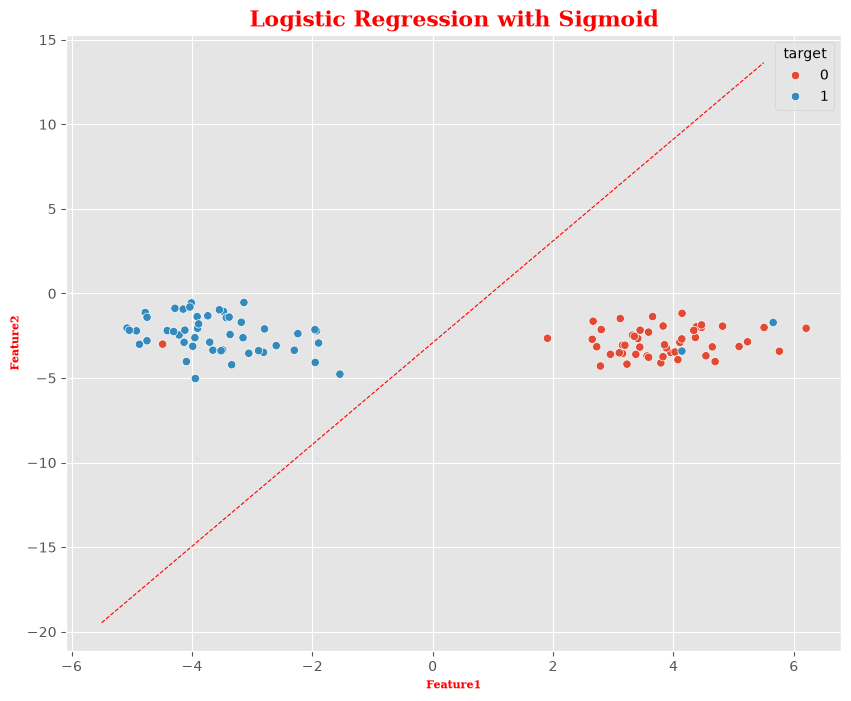

In [451]:
obj1=sigmoid(lr=0.2,epoch=10000)
obj1.fit(x_train,y_train)
prediction=obj1.predict(x_test)
accuracy_Score=accuracy(prediction,y_test).accuracy_score()
print(accuracy_Score)
import seaborn as sns 
import matplotlib.pyplot as plt
o=np.linspace(-5.5,5.5,10)
weight=obj1.weight
m=(-weight[0])/weight[1]
c=-(weight[2])/weight[1]
l=[]
for i in o:
    l.append(m*i+c)
c=np.array(c)
text={'fontsize':16,'fontweight':'bold','color':'red','loc':'center','fontfamily':'serif'}
line={'linewidth':0.8,'color':'red','linestyle':'--'}
plt.style.use('ggplot')
plt.figure(figsize=(10,8))
sns.scatterplot(df,x='feature1',y='feature2',hue='target')
plt.plot(o,l,**line)
plt.title('Logistic Regression with Sigmoid',**text)
plt.xlabel('Feature1',fontsize=8,fontweight='bold',color='red',fontfamily='serif')
plt.ylabel('Feature2',fontsize=8,fontweight='bold',color='red',fontfamily='serif')
plt.show()

